In [43]:
CSV_FILE = "./05_distrib.csv"
LID_VELOCITY = 0.1
SUBSAMPLE = 1       # use every Nth clean timestep (1 = all)
FPS = 15
OUTPUT_FILE = CSV_FILE + "moving.mp4"   # set to a path to save, or None to only display in-notebook

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# D2Q9 direction components: (x_part, y_part)
DIR = {
    0: ( 0,  0),  # NONE
    1: ( 1,  0),  # RIGHT
    2: ( 0,  1),  # UP
    3: (-1,  0),  # LEFT
    4: ( 0, -1),  # DOWN
    5: ( 1,  1),  # UP_RIGHT
    6: (-1,  1),  # UP_LEFT
    7: (-1, -1),  # DOWN_LEFT
    8: ( 1, -1),  # DOWN_RIGHT
}

In [45]:
df = pd.read_csv(CSV_FILE)

# Pivot: 9 direction columns instead of 9 rows per grid point
piv = df.pivot_table(index=['timestep', 'x', 'y'],
                      columns='dir', values='dist_value')
piv.columns = [f'd{i}' for i in range(9)]
piv.reset_index(inplace=True)

x_vals = sorted(df['x'].unique())
y_vals = sorted(df['y'].unique())
nx, ny = len(x_vals), len(y_vals)
L = nx
nodes_per_ts = nx * ny
print(f"Grid: {nx}x{ny}, L={L}")
print(f"Pivoted shape: {piv.shape}  (rows = timesteps \u00d7 nodes)")
all_ts = sorted(piv['timestep'].unique())
val_cols = [f'd{i}' for i in range(9)]
print(len(all_ts))

Grid: 128x128, L=128
Pivoted shape: (86464, 12)  (rows = timesteps × nodes)
6


In [46]:
def velocity_at_timestep(ts):
    rows = piv[piv['timestep'] == ts][val_cols].values
    dist = rows.reshape(nx, ny, 9)
    rho = dist.sum(axis=2)
    ux = np.zeros((nx, ny))
    uy = np.zeros((nx, ny))
    for d, (cx, cy) in DIR.items():
        ux += cx * dist[:, :, d]
        uy += cy * dist[:, :, d]
    ux /= rho
    uy /= rho
    return ux, uy

Saving to ./05_distrib.csvmoving.mp4...


ValueError: cannot reshape array of size 146016 into shape (128,128,9)

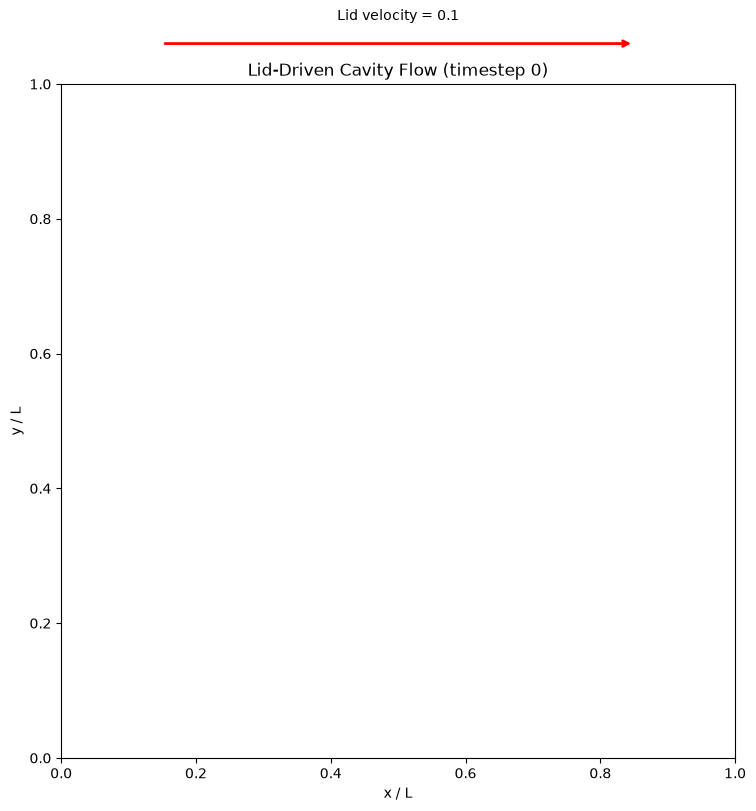

In [47]:
# Normalized coordinates
X = (np.array(y_vals) - y_vals[0]) / L   # columns
Y = (np.array(x_vals) - x_vals[0]) / L   # rows

fig, ax = plt.subplots(figsize=(8, 8))
fig.tight_layout(pad=3)

def animate(ts):
    ax.cla()
    ux, uy = velocity_at_timestep(ts)
    speed = np.sqrt(ux**2 + uy**2)

    strm = ax.streamplot(X, Y, ux, uy, color=speed, cmap='viridis',
                         density=1.5, linewidth=1)

    ax.set_xlabel('x / L')
    ax.set_ylabel('y / L')
    ax.set_title(f'Lid-Driven Cavity Flow (timestep {ts})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    ax.annotate('', xy=(0.85, 1.06), xytext=(0.15, 1.06),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'),
                annotation_clip=False)
    ax.text(0.5, 1.09, f'Lid velocity = {LID_VELOCITY}',
            ha='center', va='bottom', fontsize=10)

    return strm.lines,

anim = FuncAnimation(fig, animate, frames=all_ts)

if OUTPUT_FILE:
    print(f"Saving to {OUTPUT_FILE}...")
    anim.save(OUTPUT_FILE, writer='ffmpeg', dpi=100)
    print("Done")